In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Initialise urls

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

# all_crawls = ['ny_1', 'texas_1',
#               'male_dem_ny_1', 'male_dem_texas_1',
#               'male_rep_ny_1', 'male_rep_texas_1',
#               'female_dem_ny_1', 'female_dem_texas_1',
#               'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### Merging and preprocessing

In [5]:
flag = 'news'

if flag == 'news':
    all_urls = news_urls.copy()
elif flag == 'nonnews':
    all_urls = nonnews_urls.copy()

In [6]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():

        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            # if both comments and timestamps files are present
            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:

                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                # this particular comment is just ' '. so adding it manually.
                id_user_mapping = {
                    'DRVQXcWAaaw': 'authoryuccaharris',
                    'DSBZZEcgL4D': 'mafia__460mafia_', 
                    'DSBm_S8gC1p': 'grimreaper3716',
                    'DRYdTZHjT-E': 'danieleichenlaub',
                    'DSARqDnEhPJ': 'amadeoedgardof',
                    'DR_mqpKEr01': 'amadeoedgardof',
                    'DSC60BKkrYV': 'amadeoedgardof',
                    'DR5O3P_jycm': 'dottyeroth',
                    'DSCrwGuDxUR': 'treqpimento_',
                    'DSEn813Eo5Q': 'amadeoedgardof'

                }

                if id_ in id_user_mapping:
                    if id_user_mapping[id_] in comments:
                        idx = comments.index(id_user_mapping[id_])
                        comments = comments[:idx+1] + [' '] + comments[idx+1:]

                # mapping usernames and comments to timestamps
                comments_map = {}

                # checking if comments (username + comment) and timestamps are of same length 
                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes} # TODO: check if likes here is correct
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    # if this happens, its mostly happening since a comment is empty string ''
                    print(f'comemnts-timestamps length mismatch', account, id_, crawl)
            else:
                # only comments file is present
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)
                if len(comments) != 0:
                    if id_ == 'DSC60BKkrYV':
                        caption, comments, likes = None, [], None
                    else:
                        print('no timestamp file and len(comments) != 0', id_, account, crawl, len(comments))
                    
                    # if this happens its usually to do more cleaning of comements

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

In [7]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

male_dem_ny_1: (1062, 7)
male_dem_texas_1: (1091, 7)
male_rep_ny_1: (1155, 7)
male_rep_texas_1: (1082, 7)
female_dem_ny_1: (1087, 7)
female_dem_texas_1: (1085, 7)
female_rep_ny_1: (1089, 7)
female_rep_texas_1: (1090, 7)


In [8]:
for crawl, df in dfs.items():
    # df.drop(columns=['likes'], inplace=True, axis=1)
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [9]:
col1 = 'male_dem_ny_1'
merged_df = dfs[col1].copy()

for crawl, df in dfs.items():
    if crawl == col1:
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])
    # merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num', 'caption'])

male_dem_texas_1
male_rep_ny_1
male_rep_texas_1
female_dem_ny_1
female_dem_texas_1
female_rep_ny_1
female_rep_texas_1


In [10]:
# remove urls that have less than 10 comments

urlids = merged_df['urlid'].unique().tolist()
donotremove_urls = set()
for urlid in urlids:
    temp = merged_df[merged_df['urlid'] == urlid]
    num_rows = temp['comment_num'].max()
    if num_rows <= 8:
        continue
    else:
        donotremove_urls.add(urlid)

merged_df = merged_df[merged_df['urlid'].isin(donotremove_urls)]

In [11]:
# limiting to top 10 comments
merged_df = merged_df[merged_df['comment_num'] <= 9]
merged_df.shape

(1129, 20)

In [12]:
temp_df = get_chronological_order_comments(merged_df, all_urls, all_crawls)
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [13]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,caption,comment_num,male_dem_ny_1_comment,male_dem_texas_1_comment,male_rep_ny_1_comment,male_rep_texas_1_comment,female_dem_ny_1_comment,female_dem_texas_1_comment,female_rep_ny_1_comment,female_rep_texas_1_comment,chronological_comment
0,breitbart,DRWBiQXDG0H,wearebreitbart\n 2 d\nSpeaking to Editor-in-Ch...,0,"(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(ryan.smith202, It’s not fissures in MAGA, it ..."
1,breitbart,DRWBiQXDG0H,wearebreitbart\n 2 d\nSpeaking to Editor-in-Ch...,1,"(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs..."
2,breitbart,DRWBiQXDG0H,wearebreitbart\n 2 d\nSpeaking to Editor-in-Ch...,2,"(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(_taco_______, 🤡🤡)"
3,breitbart,DRWBiQXDG0H,wearebreitbart\n 2 d\nSpeaking to Editor-in-Ch...,3,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(loretta.bauer.35, I thought that was exactly ..."
4,breitbart,DRWBiQXDG0H,wearebreitbart\n 2 d\nSpeaking to Editor-in-Ch...,4,"(loretta.bauer.35, I thought that was exactly ...","(loretta.bauer.35, I thought that was exactly ...","(loretta.bauer.35, I thought that was exactly ...","(loretta.bauer.35, I thought that was exactly ...","(i_tr00per, Bernie Moreno has the most remedia...","(i_tr00per, Bernie Moreno has the most remedia...","(i_tr00per, Bernie Moreno has the most remedia...","(loretta.bauer.35, I thought that was exactly ...","(torinejudith, ❤️)"


In [14]:
merged_df.shape

(1279, 13)

In [15]:
merged_df.to_csv(f'/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_{flag}_comments.csv', index=False)

### Descriptive differences between News and Non-News accounts

In [5]:
news_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news.csv'
nonnews_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews.csv'

news_df = pd.read_csv(news_filepath)
nonnews_df = pd.read_csv(nonnews_filepath)

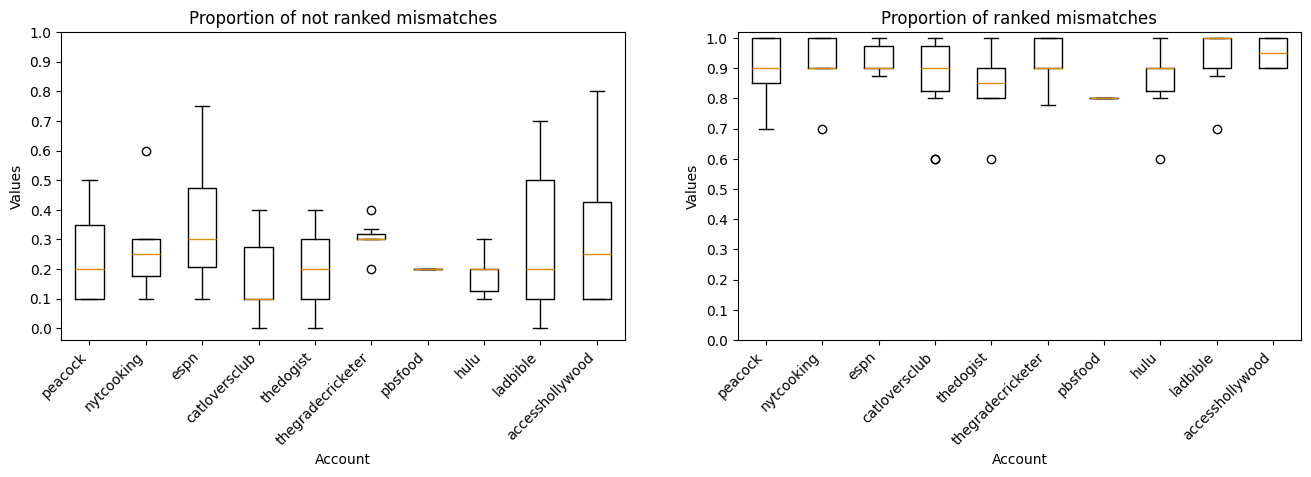

In [7]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

crawl1 = 'chronological'
crawl2 = 'male_dem_ny_1'

temp_df = plot_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, plot_urls)


accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

division by zero catloversclub DSC60BKkrYV 0 0
division by zero ladbible DSAzKDHjI_T 0 0
division by zero ladbible DSCoNYQDAK- 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero accesshollywood DSDU9GlDmn4 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catl

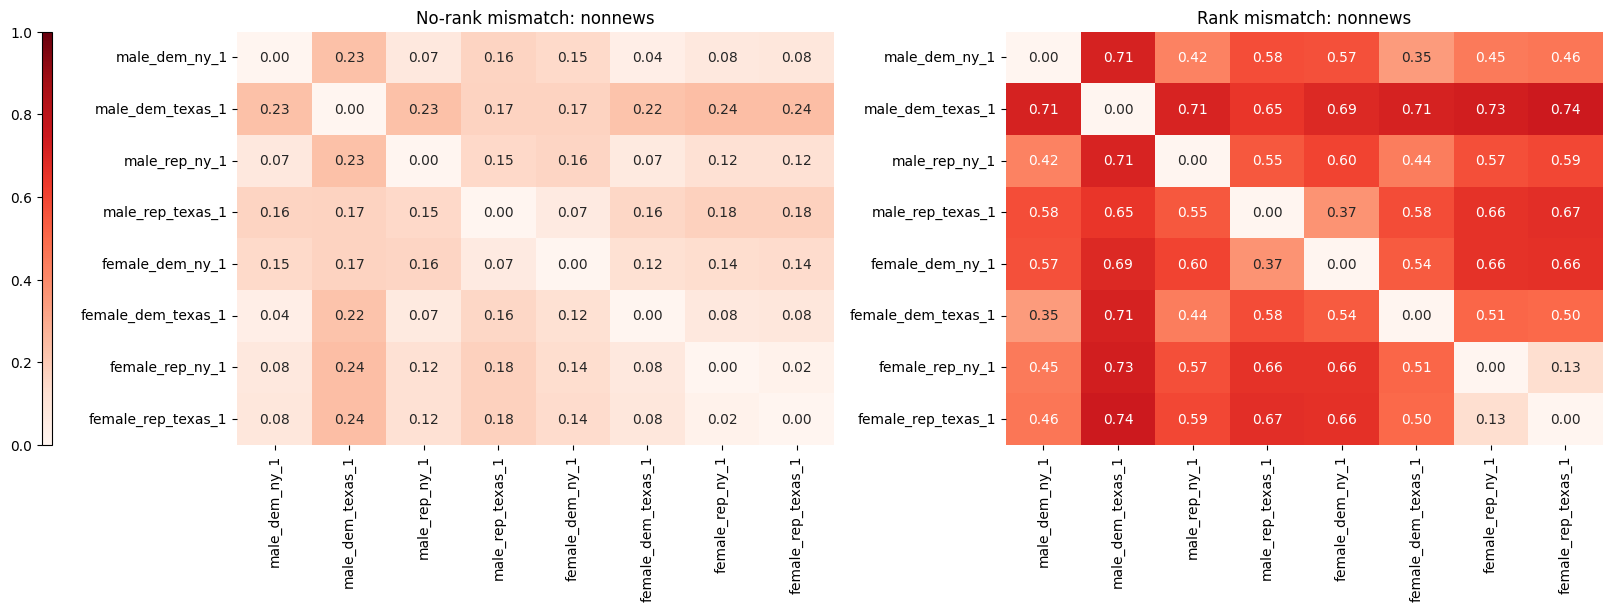

In [11]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")


fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

hm0 = sns.heatmap(
    mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[0], cbar=False
)
axes[0].set_title(f"No-rank mismatch: {flag}")

hm1 = sns.heatmap(
    mismatch_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[1], cbar=False
)
axes[1].set_title(f"Rank mismatch: {flag}")

cbar = fig.colorbar(
    hm0.collections[0],
    ax=axes,
    orientation="vertical",
    location="left", 
    pad=0.02,
    fraction=0.06,
    aspect=40
)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")

plt.show()


### Regression Analysis

In [5]:
news_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news.csv'

news_df = pd.read_csv(news_filepath)
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)
reg_news_df.shape

division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0


(4648, 9)

In [6]:
reg_news_df.drop_duplicates(inplace=True)
reg_news_df.shape

(2121, 9)

In [7]:
reg_news_df.dropna(inplace=True)
reg_news_df.shape

(2121, 9)

In [8]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='account', how='inner')
reg_news_df.shape

(2121, 15)

In [9]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_news_df = reg_news_df.merge(comments_df, on='urlid', how='left')
reg_news_df = reg_news_df.merge(likes_df, on='urlid', how='left')

reg_news_df[reg_news_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX71AeCgTh',
       'DRX7mPtkhbo', 'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z',
       'DRYGzcyEsGL', 'DRK7-xAEaGg', 'DRNAF39ESYr', 'DRNI1TVEZ90',
       'DRNOKZMkZv9', 'DRVZKhOkeKw', 'DRV4-1ck1EG', 'DRXO1Q9Co1Y'],
      dtype=object)

In [10]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='urlid', how='outer')
reg_news_df.shape

(2121, 18)

In [13]:
reg_news_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,1394.000000,727.000000
mean,853.671449,1827.634113
std,2134.126414,3092.699244
min,14.000000,17.000000
25%,89.000000,116.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [14]:
reg_news_df['comments_count'] = reg_news_df["comments_count"].fillna(reg_news_df["comments_mising"])
reg_news_df[['comments_count', 'comments_mising']].describe()
reg_news_df.drop(columns=['comments_mising'], inplace=True)

#### only political reg

In [15]:
reg_news_df['fcount_no_rank'] = reg_news_df['fcount_no_rank'].astype(int)
reg_news_df['ftrials_no_rank'] = reg_news_df['ftrials_no_rank'].astype(int)
reg_news_df['fcount_rank'] = reg_news_df['fcount_rank'].astype(int)
reg_news_df['ftrials_rank'] = reg_news_df['ftrials_rank'].astype(int)

(reg_news_df[reg_news_df['fcount_no_rank'] > reg_news_df['ftrials_no_rank']]).shape, (reg_news_df[reg_news_df['fcount_rank'] > reg_news_df['ftrials_rank']]).shape

((0, 17), (0, 17))

In [16]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_news_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_news_df['urlid'].nunique()

reg_news_df = pd.merge(reg_news_df, posts_data, on='urlid', how='inner')
reg_news_df.drop(columns=['Url'], inplace=True)
reg_news_df.shape

(2121, 21)

In [17]:
reg_news_df['political_ideology'] = reg_news_df['political_ideology'].replace({'Right': 'Right',
                                      'Center-Left': 'Left',
                                      'Center': 'Center',
                                      'Left': 'Left',
                                      'Center-Right': 'Right'})

reg_news_df['political_ideology'].value_counts()

political_ideology
Left      941
Right     754
Center    426
Name: count, dtype: int64

In [18]:
reg_news_df['ideology'].value_counts()

ideology
dem_rep    1179
dem_dem     471
rep_rep     471
Name: count, dtype: int64

In [19]:
reg_news_df['gender_diff'] = reg_news_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
reg_news_df['location_diff'] = reg_news_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
reg_news_df['ideology_diff'] = reg_news_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [20]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(reg_news_df[col].astype(float))
    reg_news_df[new_col] = (x - x.mean()) / x.std()

reg_news_df["gender"] = pd.Categorical(
    reg_news_df["gender"],
    categories=["female_female", "male_male", "female_male"],
    ordered=True
)

reg_news_df["ideology"] = pd.Categorical(
    reg_news_df["ideology"],
    categories=["dem_dem", "rep_rep", "dem_rep"],
    ordered=True
)

reg_news_df["location"] = pd.Categorical(
    reg_news_df["location"],
    categories=["ny_ny", "texas_texas", "ny_texas"],
    ordered=True
)

reg_news_df['main_topic'] = pd.Categorical(
    reg_news_df['main_topic'],
    categories=['Political', 'Non-Political'],
    ordered=True
)

reg_news_df["gender_diff"] = pd.Categorical(
    reg_news_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_news_df["ideology_diff"] = pd.Categorical(
    reg_news_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_news_df["location_diff"] = pd.Categorical(
    reg_news_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

In [21]:
reg_news_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,Brahmani_Topics,Divya_Topics,Hamayoon_Topics,main_topic,gender_diff,location_diff,ideology_diff,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,DRK7-xAEaGg,thehill,0,18,2,9,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,No,Yes,No,0.037838,-2.151076,-2.10613,-0.406964
1,ny_ny,male_male,dem_rep,DRK7-xAEaGg,thehill,3,19,5,10,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,No,No,Yes,0.037838,-2.151076,-2.10613,-0.406964
2,ny_texas,male_male,dem_rep,DRK7-xAEaGg,thehill,3,19,5,10,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,No,Yes,Yes,0.037838,-2.151076,-2.10613,-0.406964
3,ny_ny,female_male,dem_dem,DRK7-xAEaGg,thehill,0,18,0,9,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,Yes,No,No,0.037838,-2.151076,-2.10613,-0.406964
4,ny_texas,female_male,dem_dem,DRK7-xAEaGg,thehill,0,18,0,9,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,Political,Political,Political,Political,Yes,Yes,No,0.037838,-2.151076,-2.10613,-0.406964


In [22]:
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(political_ideology) + C(reporting_quality) + C(credibility) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(political_ideology) + C(credibility) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(political_ideology) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(political_ideology) + C(main_topic) + comments_count_logz" 
get_vif(formula, reg_news_df)

,feature,VIF
1,gender_diff[T.Yes],1.089110
3,ideology_diff[T.Yes],1.089727
2,location_diff[T.Yes],1.104889
6,C(main_topic)[T.Non-Political],1.176210
7,comments_count_logz,1.289241
5,C(political_ideology)[T.Right],2.082669
4,C(political_ideology)[T.Left],2.190639
0,Intercept,12.333189


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, political_ideology, main_topic, comments_count_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 106 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,8.365,0.631,7.196,9.558,0.009,0.008,5308.0,5143.0,1.0
Intercept,-2.773,0.399,-3.526,-1.997,0.014,0.008,824.0,1307.0,1.0
location_diff[Yes],-0.257,0.059,-0.366,-0.144,0.001,0.001,4547.0,5004.0,1.0
gender_diff[Yes],0.241,0.059,0.134,0.354,0.001,0.001,5938.0,5821.0,1.0
ideology_diff[Yes],0.321,0.061,0.215,0.445,0.001,0.001,5175.0,5314.0,1.0
...,...,...,...,...,...,...,...,...,...
1|urlid[DRYeCC9DP9C],-2.461,0.817,-4.028,-1.015,0.014,0.010,3286.0,4454.0,1.0
1|urlid[DRYfrKnDJXa],0.567,0.385,-0.163,1.272,0.011,0.006,1127.0,2236.0,1.0
1|urlid[DRYg5_ZlC-O],-0.224,0.424,-0.998,0.591,0.013,0.007,1151.0,2356.0,1.0
1|urlid[DRYi49Elhfc],-1.985,0.862,-3.679,-0.465,0.014,0.010,3740.0,4830.0,1.0


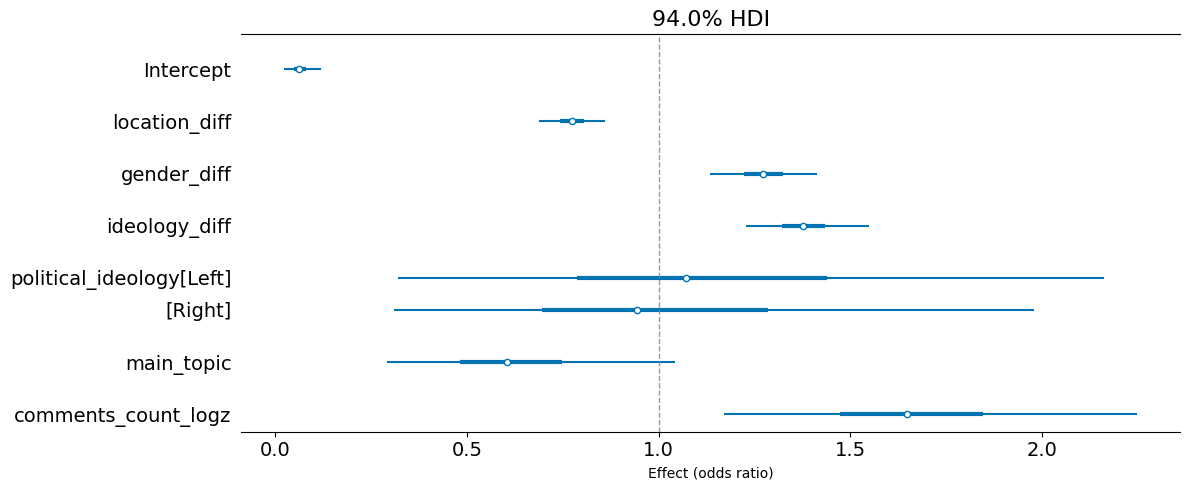

In [23]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + political_ideology + main_topic + comments_count_logz + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    # random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'political_ideology', 'main_topic', 'comments_count_logz']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, political_ideology, ideology_diff:political_ideology, main_topic, comments_count_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 93 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,8.367,0.612,7.265,9.572,0.008,0.007,5365.0,5310.0,1.0
Intercept,-2.894,0.398,-3.643,-2.135,0.013,0.008,938.0,1152.0,1.0
location_diff[Yes],-0.256,0.061,-0.364,-0.140,0.001,0.001,6043.0,5457.0,1.0
gender_diff[Yes],0.239,0.059,0.126,0.347,0.001,0.001,6092.0,5950.0,1.0
ideology_diff[Yes],0.522,0.156,0.223,0.803,0.003,0.002,2757.0,3774.0,1.0
...,...,...,...,...,...,...,...,...,...
1|urlid[DRYeCC9DP9C],-2.389,0.804,-3.950,-0.986,0.012,0.010,4801.0,4782.0,1.0
1|urlid[DRYfrKnDJXa],0.527,0.377,-0.154,1.252,0.011,0.006,1130.0,2309.0,1.0
1|urlid[DRYg5_ZlC-O],-0.260,0.408,-1.066,0.467,0.012,0.006,1185.0,2254.0,1.0
1|urlid[DRYi49Elhfc],-1.914,0.864,-3.531,-0.386,0.014,0.011,4014.0,4569.0,1.0


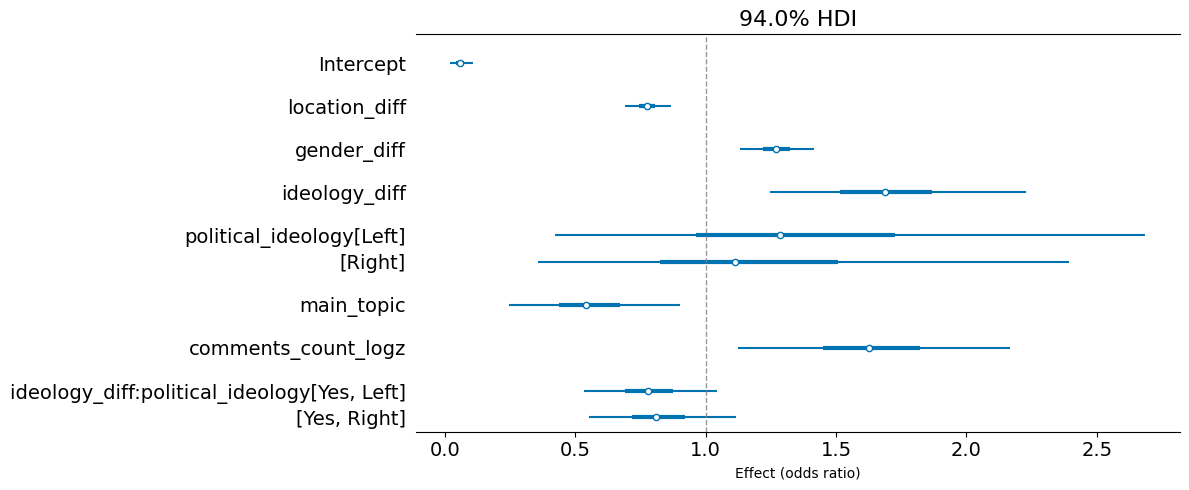

In [22]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff * political_ideology + main_topic + comments_count_logz + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    # random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'political_ideology', 'main_topic', 'comments_count_logz', 'ideology_diff:political_ideology']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

In [23]:
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(political_ideology) + C(reporting_quality) + C(credibility) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(political_ideology) + C(credibility) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(political_ideology) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(political_ideology) + C(main_topic) + comments_count_logz" 
get_vif(formula, reg_news_df)

,feature,VIF
9,C(main_topic)[T.Non-Political],1.139084
10,comments_count_logz,1.303727
1,C(location)[T.texas_texas],1.537034
3,C(gender)[T.male_male],1.554628
5,C(ideology)[T.rep_rep],1.555985
2,C(location)[T.ny_texas],1.641607
4,C(gender)[T.female_male],1.644685
6,C(ideology)[T.dem_rep],1.645561
8,C(political_ideology)[T.Right],2.079847
7,C(political_ideology)[T.Left],2.180697


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location, gender, ideology, political_ideology, main_topic, comments_count_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 118 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,10.188,0.815,8.642,11.711,0.010,0.010,6318.0,5571.0,1.0
Intercept,-3.777,0.409,-4.548,-3.004,0.011,0.008,1330.0,2168.0,1.0
location[texas_texas],0.153,0.076,0.008,0.292,0.001,0.001,5170.0,5816.0,1.0
location[ny_texas],-0.186,0.069,-0.326,-0.066,0.001,0.001,4882.0,5754.0,1.0
gender[male_male],0.659,0.089,0.491,0.822,0.001,0.001,4747.0,5404.0,1.0
...,...,...,...,...,...,...,...,...,...
1|urlid[DRYeCC9DP9C],-2.470,0.842,-4.099,-0.965,0.013,0.011,4109.0,4099.0,1.0
1|urlid[DRYfrKnDJXa],0.501,0.387,-0.204,1.263,0.010,0.007,1367.0,1776.0,1.0
1|urlid[DRYg5_ZlC-O],-0.285,0.427,-1.114,0.504,0.011,0.007,1438.0,1797.0,1.0
1|urlid[DRYi49Elhfc],-1.980,0.904,-3.703,-0.378,0.014,0.012,4655.0,4447.0,1.0


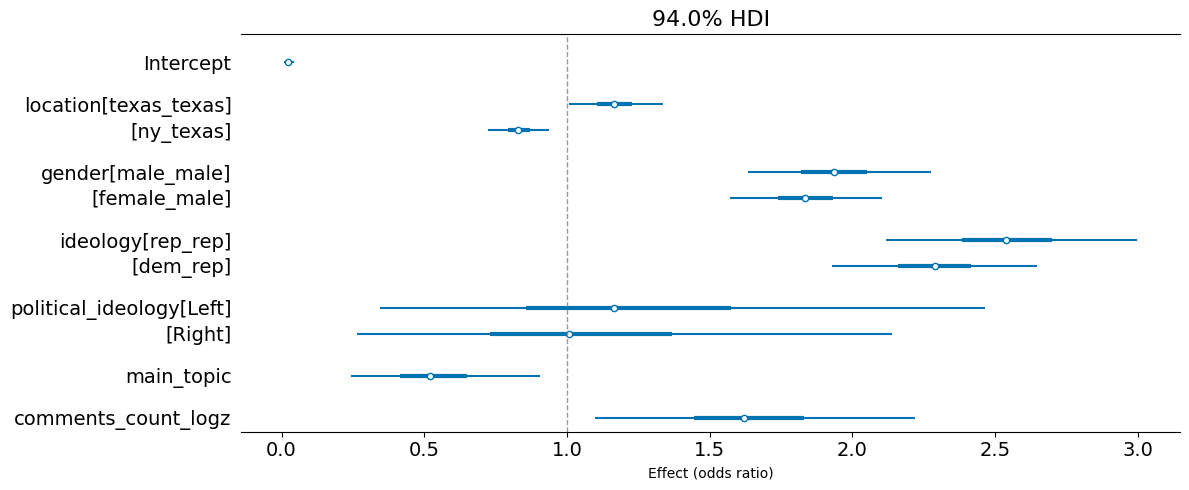

In [24]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + political_ideology + main_topic + comments_count_logz + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    # random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names = ['Intercept', 'location', 'gender', 'ideology', 'political_ideology', 'main_topic', 'comments_count_logz']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, political_ideology, ideology:political_ideology, main_topic, comments_count_logz, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 567 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,10.334,0.838,8.801,11.928,0.009,0.012,8642.0,5078.0,1.0
Intercept,-4.368,0.465,-5.243,-3.511,0.010,0.007,2044.0,3036.0,1.0
location[texas_texas],0.157,0.077,0.019,0.306,0.001,0.001,7676.0,6161.0,1.0
location[ny_texas],-0.183,0.070,-0.310,-0.048,0.001,0.001,7315.0,5921.0,1.0
gender[male_male],0.661,0.091,0.487,0.828,0.001,0.001,7398.0,6022.0,1.0
...,...,...,...,...,...,...,...,...,...
1|urlid[DRYeCC9DP9C],-2.467,0.829,-3.984,-0.935,0.011,0.012,5836.0,4522.0,1.0
1|urlid[DRYfrKnDJXa],0.512,0.384,-0.195,1.241,0.008,0.005,2250.0,3504.0,1.0
1|urlid[DRYg5_ZlC-O],-0.285,0.423,-1.063,0.521,0.009,0.006,2377.0,4013.0,1.0
1|urlid[DRYi49Elhfc],-2.018,0.902,-3.748,-0.411,0.011,0.011,6853.0,4911.0,1.0


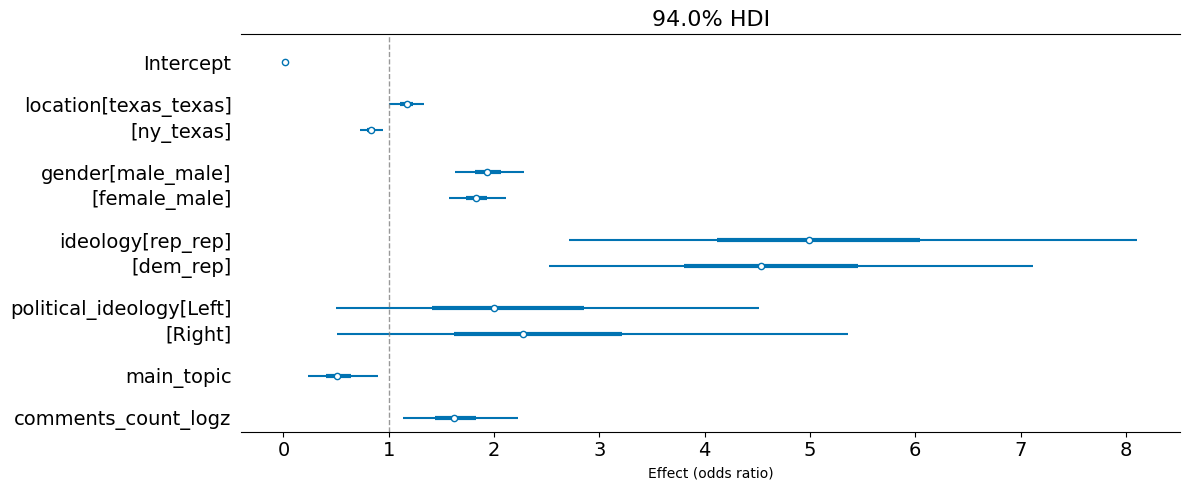

In [26]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology * political_ideology + main_topic + comments_count_logz + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=1,
    # random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names = ['Intercept', 'location', 'gender', 'ideology', 'political_ideology', 'main_topic', 'comments_count_logz']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()